# LDA
* Vectorization with BoW
* LDA algorithm
* Evaluation with perplexity and coherence
* Visualization with PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim import corpora
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.preprocessing import normalize

import pyLDAvis
import pyLDAvis.lda_model

In [2]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big, bang]"
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."


In [3]:
from gensim.models.phrases import Phrases, Phraser
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load tokens (already preprocessed)
tokenized_docs = df["post_tokens"].tolist()

# 2. Detect and apply bigrams (tokens → tokens)
phrases = Phrases(tokenized_docs, min_count=5, threshold=10)
bigram = Phraser(phrases)
merged_docs = [bigram[doc] for doc in tokenized_docs]

# 3. Join tokens for vectorization (only here!)
merged_texts = [" ".join(doc) for doc in merged_docs]

# 4. Vectorize
vectorizer = CountVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 1)
)
X = vectorizer.fit_transform(merged_texts)

# 5. Train LDA
lda = LatentDirichletAllocation(
    n_components=10,
    max_iter=10,
    learning_method='online',  # Enables mini-batch updates
    batch_size=1024,           # Number of documents per batch
    evaluate_every=5,         # Evaluate perplexity every 5 batches
    n_jobs=-1,                # Use all CPU cores
    random_state=42
)
lda.fit(X)

KeyboardInterrupt: 

In [ ]:
# Convert tokens to string vectorization
# df["clean_text"] = df["post_tokens"].apply(lambda x: " ".join(x))
# df.head(5)

## BoW

In [ ]:
# Improved (with bigrams)
vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  # unigrams + bigrams
    min_df=5,
    max_df=0.8
)

# Fit and transform 'clean text'
X = vectorizer.fit_transform(df["clean_text"])

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

10000
['00' '00 00' '00 foot' ... 'zoo' 'zoom' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4658815 stored elements and shape (590938, 10000)>
  Coords	Values
  (0, 9070)	1
  (0, 2281)	1
  (0, 915)	1
  (0, 821)	1
  (0, 916)	1
  (1, 9332)	1
  (1, 3963)	1
  (1, 7836)	1
  (1, 3285)	1
  (1, 3168)	1
  (1, 5803)	1
  (1, 7843)	1
  (2, 1788)	1
  (2, 5031)	1
  (2, 3350)	1
  (2, 5797)	1
  (2, 6463)	1
  (2, 6947)	1
  (2, 3808)	1
  (3, 1572)	1
  (3, 1217)	1
  (3, 5114)	1
  (3, 8900)	1
  (3, 7288)	1
  (4, 2154)	1
  :	:
  (590933, 9534)	1
  (590933, 354)	1
  (590933, 2320)	2
  (590933, 5974)	1
  (590933, 315)	1
  (590934, 3199)	1
  (590934, 1889)	1
  (590935, 9070)	1
  (590935, 2635)	1
  (590935, 6312)	1
  (590935, 7773)	1
  (590936, 4384)	1
  (590936, 3325)	1
  (590936, 5329)	1
  (590936, 169)	1
  (590936, 6502)	1
  (590936, 1623)	1
  (590936, 9230)	1
  (590936, 9225)	1
  (590936, 9196)	1
  (590937, 2760)	1
  (590937, 6754)	1
  (590937, 7934)	1
  (590937, 588)	1
  (590937, 

## LDA

### Finding the Best Value for *k*

In [ ]:
texts = df["post_tokens"].tolist()
dictionary = corpora.Dictionary(texts)

def train_lda(k, X):
    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=10,
        random_state=42,
        n_jobs=-1,
        batch_size=8192,
        evaluate_every=-1
    )
    lda.fit(X)
    return lda

In [ ]:
def evaluate_model(lda, X, vectorizer, texts, dictionary, top_n=10):

    # Perplexity
    perplexity = lda.perplexity(X)

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in lda.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, perplexity, diversity

In [ ]:
# Broad range for k to find sensible range
k_values = range(5, 61, 5)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, texts, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

Training LDA with k=5
Training LDA with k=10
Training LDA with k=15
Training LDA with k=20
Training LDA with k=25
Training LDA with k=30
Training LDA with k=35
Training LDA with k=40
Training LDA with k=45
Training LDA with k=50
Training LDA with k=55
Training LDA with k=60
Training LDA with k=65
Training LDA with k=70


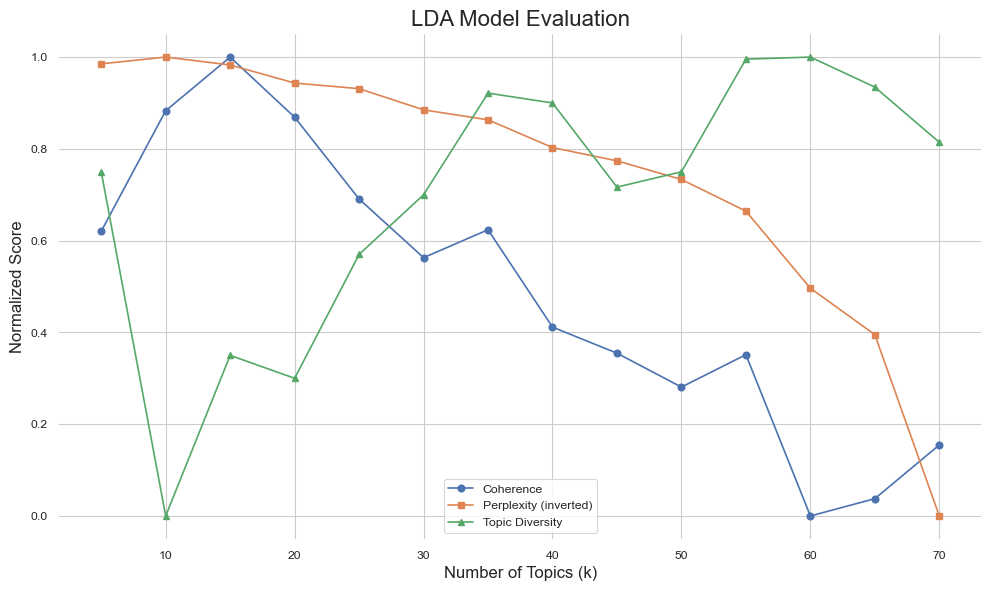

In [ ]:
sns.set_theme(style='whitegrid', context='paper')

k_vals = [r[0] for r in results]

coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()

# Invert perplexity (lower score is better)
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()

diversity_norm = scaler.fit_transform(diversity).flatten()

plt.figure(figsize=(10,6))

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

plt.xlabel("Number of Topics (k)", fontsize=12)
plt.ylabel("Normalized Score", fontsize=12)
plt.title("LDA Model Evaluation", fontsize=16)

plt.legend()
plt.grid(visible=True)

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics_5-100-5.png', dpi=300)

plt.show()

From the broad overview two relevant areas can be identified. The inverted perplexity score stays relatively constant until k=55 and drops afterwards indicating that *k* should be *< 55*. The coherence score drops sharply right in the beginning and shows two smaller spikes at *k = 30* and *k = 60*. A higher coherence score is desirable for sematically meaniful topics which seems to be quite difficult here. As an additional metric topic diversity was plotted to measure the disctincness of topics. Unlike the coeherence score it rises rapidly with increasing *k* until its peak at *k = 50*. A good tradeoff between coherence and diversity seems to be in the range *k = 5* to *k = 35* which will be investigated with smaller steps in the following.

In [ ]:
# Narrow range for k to find the best k
k_values = range(2, 26, 1)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, texts, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

k_vals = [r[0] for r in results]

Training LDA with k=2
Training LDA with k=3
Training LDA with k=4
Training LDA with k=5
Training LDA with k=6
Training LDA with k=7
Training LDA with k=8
Training LDA with k=9
Training LDA with k=10
Training LDA with k=11
Training LDA with k=12
Training LDA with k=13
Training LDA with k=14
Training LDA with k=15
Training LDA with k=16
Training LDA with k=17
Training LDA with k=18
Training LDA with k=19
Training LDA with k=20
Training LDA with k=21
Training LDA with k=22
Training LDA with k=23
Training LDA with k=24
Training LDA with k=25
Training LDA with k=26
Training LDA with k=27
Training LDA with k=28
Training LDA with k=29
Training LDA with k=30
Training LDA with k=31
Training LDA with k=32
Training LDA with k=33
Training LDA with k=34
Training LDA with k=35
Training LDA with k=36
Training LDA with k=37
Training LDA with k=38
Training LDA with k=39
Training LDA with k=40
Training LDA with k=41
Training LDA with k=42
Training LDA with k=43
Training LDA with k=44
Training LDA with k

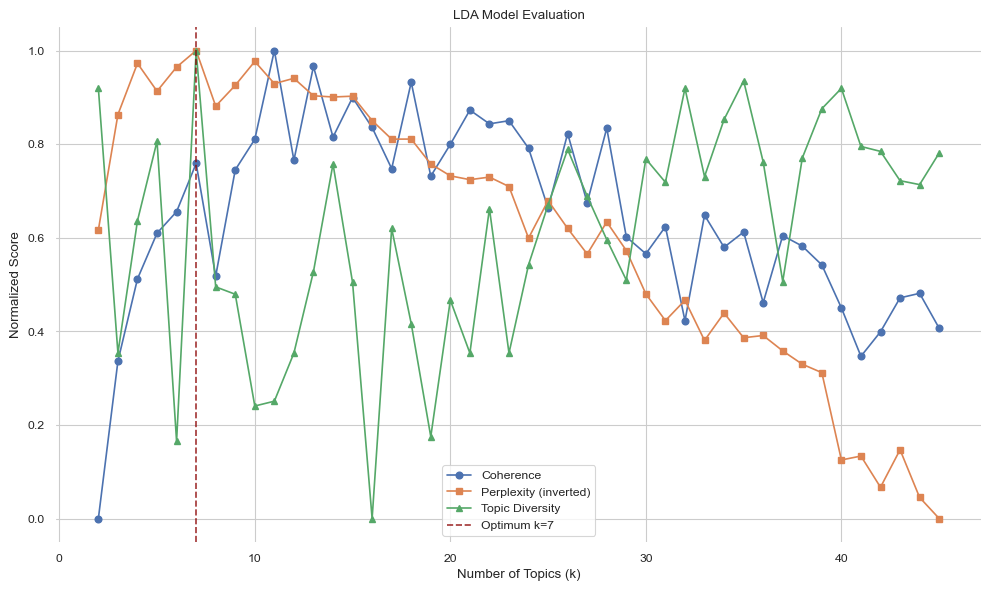

In [ ]:
coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()

# Invert perplexity (lower score is better)
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()

diversity_norm = scaler.fit_transform(diversity).flatten()

plt.figure(figsize=(10, 6))

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

# Highlight best k
plt.axvline(7, color='darkred', linestyle='--', label='Optimum k=7', alpha=0.8)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation")

plt.legend()
plt.grid(visible=True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics-2-40-1.png', dpi=300)

plt.show()

### Final Run with Best Values for *k*

In [ ]:
def show_topics(model, vectorizer, n_words=20):
    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {top_words}")

In [ ]:
def plot_2D_projection(lda, X, k):

    # Document-topic matrix
    doc_topics = lda.transform(X).astype("float32")

    # Remove weak memberships
    doc_topics[doc_topics < 0.05] = 0

    # Renormalize
    doc_topics = normalize(doc_topics, norm='l1')

    # Dominant topic
    dominant_topic = doc_topics.argmax(axis=1)
    num_topics = doc_topics.shape[1]

    # Colors based on dominant topic
    cmap = plt.colormaps.get_cmap('tab20')
    topic_colors = [cmap(t % 20) for t in dominant_topic]

    sns.set_theme(style='whitegrid', context='paper')
    spine_color = '#cccccc'

    # PCA
    pca = PCA(n_components=2, svd_solver='randomized', random_state=42)
    W_pca = pca.fit_transform(doc_topics)

    # Denoise with PCA
    # doc_topics = PCA(n_components=10).fit_transform(doc_topics)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.5,
        metric='euclidean',
        n_jobs=-1
    )

    W_umap = reducer.fit_transform(doc_topics)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    titles = ["PCA Projection", "UMAP Projection"]

    for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
        ax.scatter(
            emb[:, 0], emb[:, 1],
            c=topic_colors,
            s=6,
            alpha=0.6
        )

        ax.set_title(f"{title} of LDA Topic Space (k={k})", fontsize=15)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(alpha=0.3)

        for spine in ax.spines.values():
            spine.set_color(spine_color)

    # Legend
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(t % 20),
            markersize=8,
            label=f"Topic {t}"
        )
        for t in range(num_topics)
    ]

    axes[1].legend(
        handles=legend_elements,
        title="Topics",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(f'viz/LDA_pca_vs_umap_k{k}.png', dpi=300)

    plt.show()

In [ ]:
def get_topic_labels(model, vectorizer, n_words=5):
    words = vectorizer.get_feature_names_out()
    
    labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        labels[i] = " | ".join(top_words)

    return labels

In [ ]:
k = 7

lda = train_lda(k, X)

doc_topics = lda.transform(X)

df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

topic_labels = get_topic_labels(lda, vectorizer)

df["topic_label"] = df["topic"].map(topic_labels)

show_topics(lda, vectorizer)

Topic 0: ['produce', 'memory', 'age', 'control', 'know', 'process', 'person', 'way', 'different', 'create', 'power', 'like', 'hear', 'time', 'use', 'energy', 'sound', 'possible', 'work', 'brain']
Topic 1: ['time', 'hard', 'don', 'hair', 'come', 'hand', 'long', 'bad', 'day', 'smell', 'thing', 'light', 'look', 'sleep', 'cause', 'happen', 'eye', 'like', 'feel', 'people']
Topic 2: ['oxygen', 'possible', 'need', 'pressure', 'like', 'liquid', 'high', 'ocean', 'gas', 'hot', 'happen', 'drink', 'cold', 'color', 'body', 'air', 'food', 'heat', 'temperature', 'water']
Topic 3: ['like', 'energy', 'fast', 'star', 'travel', 'mass', 'moon', 'speed', 'possible', 'gravity', 'black_hole', 'sun', 'object', 'universe', 'happen', 'planet', 'time', 'space', 'light', 'earth']
Topic 4: ['get', 'death', 'drug', 'happen', 'cancer', 'climate_change', 'disease', 'increase', 'person', 'affect', 'people', 'virus', '19', 'cell', 'vaccine', 'life', 'cause', 'effect', 'covid', 'body']
Topic 5: ['people', 'real', 'under

In [ ]:
# Viz
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

pyLDAvis.display(viz)

## Plot Results

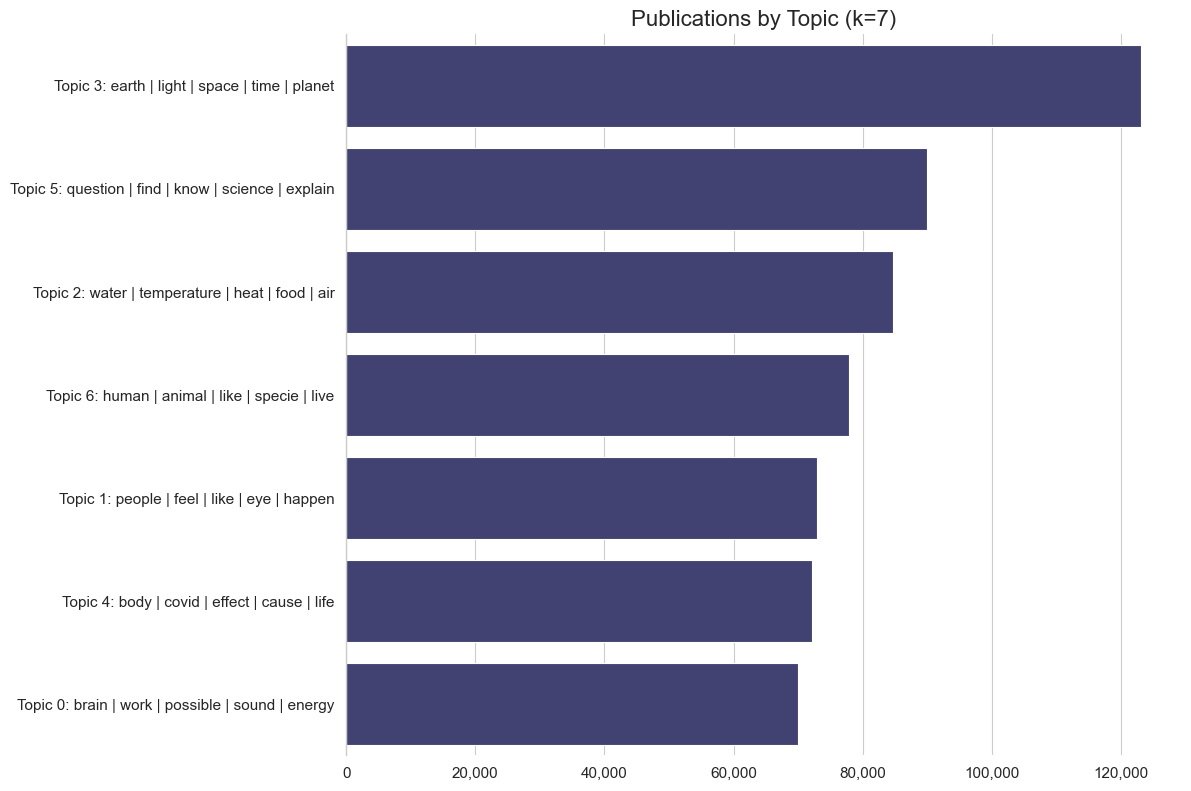

In [ ]:
words = vectorizer.get_feature_names_out()

topic_labels = {}

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-5:][::-1]]
    topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)

df["topic_label"] = df["topic"].map(topic_labels)

color = plt.colormaps["tab20b"](0)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    y="topic_label",
    order=df["topic_label"].value_counts().index,
    ax=ax,
    color=color
)

ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=11)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(f"viz/LDA_posts_per_topic_k{k}.png", dpi=300)
plt.show()

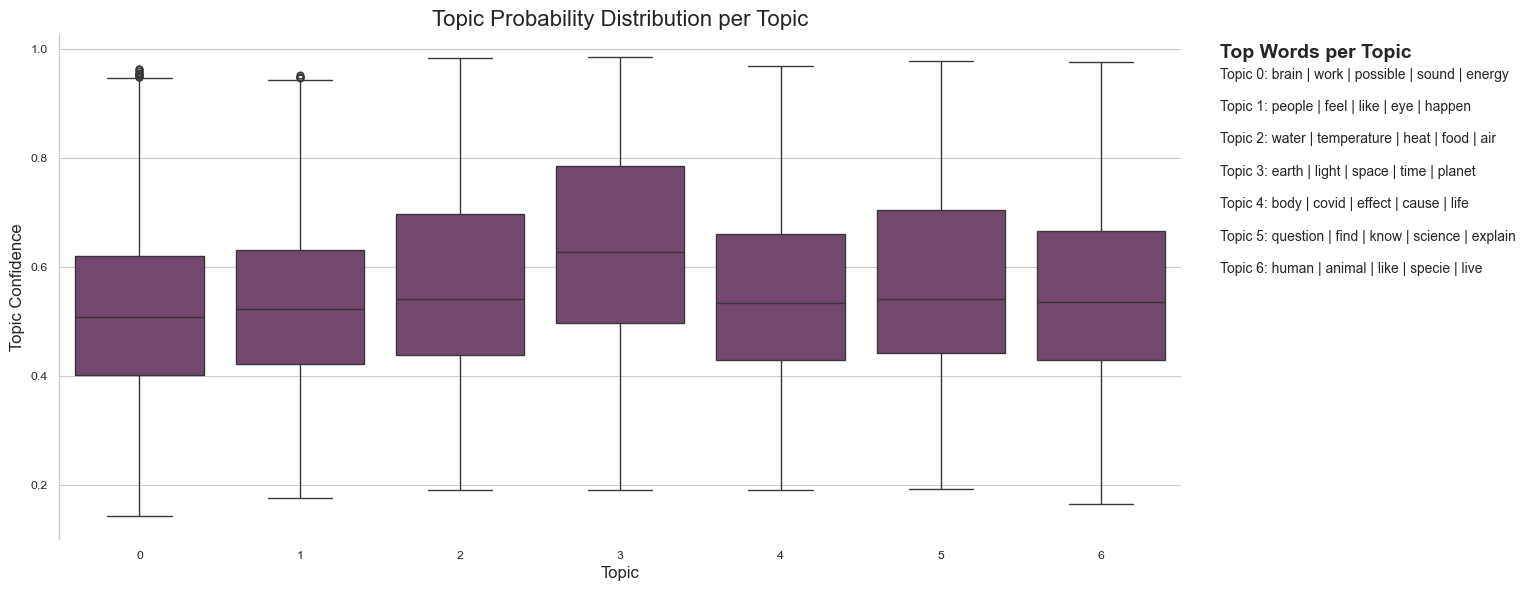

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="topic",
    y="topic_prob",
    color=plt.colormaps["tab20b"](16),
    ax=ax
)

# Titles and labels
ax.set_title("Topic Probability Distribution per Topic", fontsize=16)
ax.set_xlabel("Topic", fontsize=12)
ax.set_ylabel("Topic Confidence", fontsize=12)

# Despine plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Build topic labels
words = vectorizer.get_feature_names_out()

topic_labels = {
    i: " | ".join(
        [words[j] for j in lda.components_[i].argsort()[-5:][::-1]]
    )
    for i in range(len(lda.components_))
}

# Build legend with top words
fig.text(
    1.02, 0.92,
    "Top Words per Topic",
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)
legend_text = "\n\n".join(
    [f"Topic {i}: {topic_labels[i]}" for i in sorted(topic_labels)]
)
fig.text(
    1.02, 0.88,
    legend_text,
    fontsize=10,
    va="top",
    ha="left"
)

fig.subplots_adjust(right=0.7)

plt.tight_layout()
plt.savefig("viz/LDA_topic_confidence.png", dpi=300)
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models.phrases import Phrases, Phraser
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big, bang]"
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."


In [3]:
# --- 1. Load and Prepare Data ---
tokenized_docs = df["post_tokens"].tolist()

# --- 2. Bigram Detection and Merging ---
phrases = Phrases(tokenized_docs, min_count=5, threshold=10)
bigram = Phraser(phrases)
merged_docs = [bigram[doc] for doc in tokenized_docs]


=== Phase 1: Wide range (k=5 to 60, step=5) ===
Training LDA with k=5...
Training LDA with k=10...
Training LDA with k=15...
Training LDA with k=20...
Training LDA with k=25...
Training LDA with k=30...
Training LDA with k=35...
Training LDA with k=40...
Training LDA with k=45...
Training LDA with k=50...
Training LDA with k=55...
Training LDA with k=60...


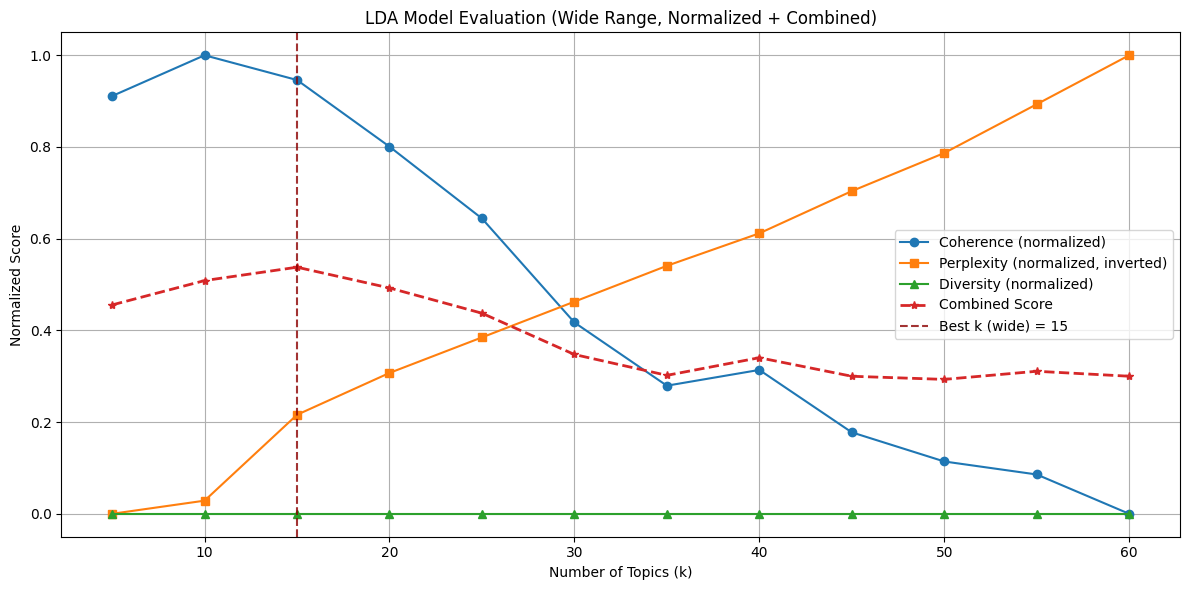

In [ ]:
# --- 3. Create Dictionary and Corpus ---
dictionary = Dictionary(merged_docs)
dictionary.filter_extremes(no_below=5, no_above=0.8, keep_n=10000)
corpus = [dictionary.doc2bow(doc) for doc in merged_docs]

# --- 4. Helper: Compute Metrics for a Model ---
def evaluate_model(model, corpus, texts, dictionary):
    # Coherence
    coherence_model = CoherenceModel(
        model=model, texts=texts, dictionary=dictionary, coherence='c_v'
    )
    coherence = coherence_model.get_coherence()

    # Perplexity (lower is better)
    perplexity = model.log_perplexity(corpus)

    # Topic Diversity: Measure uniqueness of terms across topics
    # Collect all top terms for all topics
    all_top_terms = []
    for topic_id in range(model.num_topics):
        top_terms = [term for term, _ in model.show_topic(topic_id, topn=20)]
        all_top_terms.append(top_terms)

    # Flatten the list and count term frequencies across topics
    from collections import defaultdict
    term_counts = defaultdict(int)
    for topic_terms in all_top_terms:
        for term in topic_terms:
            term_counts[term] += 1

    # Calculate diversity: average inverse frequency of terms (higher = more unique)
    diversity = 0
    for topic_terms in all_top_terms:
        for term in topic_terms:
            # Inverse frequency: 1 / (number of topics containing the term)
            diversity += 1 / term_counts[term]
    # Normalize by number of terms
    diversity /= (model.num_topics * 20)

    return coherence, perplexity, diversity

# --- 5. Two-Phase k Search ---
# Phase 1: Wide range (k=5 to 60, step=5)
print("=== Phase 1: Wide range (k=5 to 60, step=5) ===")
wide_k_values = list(range(5, 61, 5))
wide_coherence = []
wide_perplexity = []
wide_diversity = []

for k in wide_k_values:
    print(f"Training LDA with k={k}...")
    model = LdaMulticore(
        corpus=corpus, id2word=dictionary, num_topics=k,
        passes=5, chunksize=1024, workers=4, random_state=42
    )
    coherence, perplexity, diversity = evaluate_model(model, corpus, merged_docs, dictionary)
    wide_coherence.append(coherence)
    wide_perplexity.append(perplexity)
    wide_diversity.append(diversity)

# Normalize wide range metrics
scaler = MinMaxScaler()
wide_coherence_norm = scaler.fit_transform(np.array(wide_coherence).reshape(-1, 1)).flatten()
wide_perplexity_norm = 1 - scaler.fit_transform(np.array(wide_perplexity).reshape(-1, 1)).flatten()
wide_diversity_norm = scaler.fit_transform(np.array(wide_diversity).reshape(-1, 1)).flatten()

# Calculate combined score
coherence_weight = 0.5
perplexity_weight = 0.3
diversity_weight = 0.2
wide_combined = (
    coherence_weight * wide_coherence_norm +
    perplexity_weight * wide_perplexity_norm +
    diversity_weight * wide_diversity_norm
)

# Plot wide range results
plt.figure(figsize=(12, 6))
plt.plot(wide_k_values, wide_coherence_norm, label='Coherence (normalized)', marker='o')
plt.plot(wide_k_values, wide_perplexity_norm, label='Perplexity (normalized, inverted)', marker='s')
plt.plot(wide_k_values, wide_diversity_norm, label='Diversity (normalized)', marker='^')
plt.plot(wide_k_values, wide_combined, label='Combined Score', marker='*', linestyle='--', linewidth=2)

# Add vertical line for best k in wide range
best_k_wide = wide_k_values[np.argmax(wide_combined)]
plt.axvline(x=best_k_wide, color='darkred', linestyle='--', label=f'Best k (wide) = {best_k_wide}', alpha=0.8)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation (Wide Range, Normalized + Combined)")
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.savefig('viz/LDA_wide_range_normalized_combined.png', dpi=300)
plt.show()

# Select narrow range based on combined score
narrow_start = max(5, best_k_wide - 4)
narrow_end = min(60, best_k_wide + 4)


Best k in wide range: 15. Narrow range: 11 to 19.

=== Phase 2: Narrow range (k=11 to 19, step=1) ===
Training LDA with k=11...
Training LDA with k=12...
Training LDA with k=13...
Training LDA with k=14...
Training LDA with k=15...
Training LDA with k=16...
Training LDA with k=17...
Training LDA with k=18...
Training LDA with k=19...


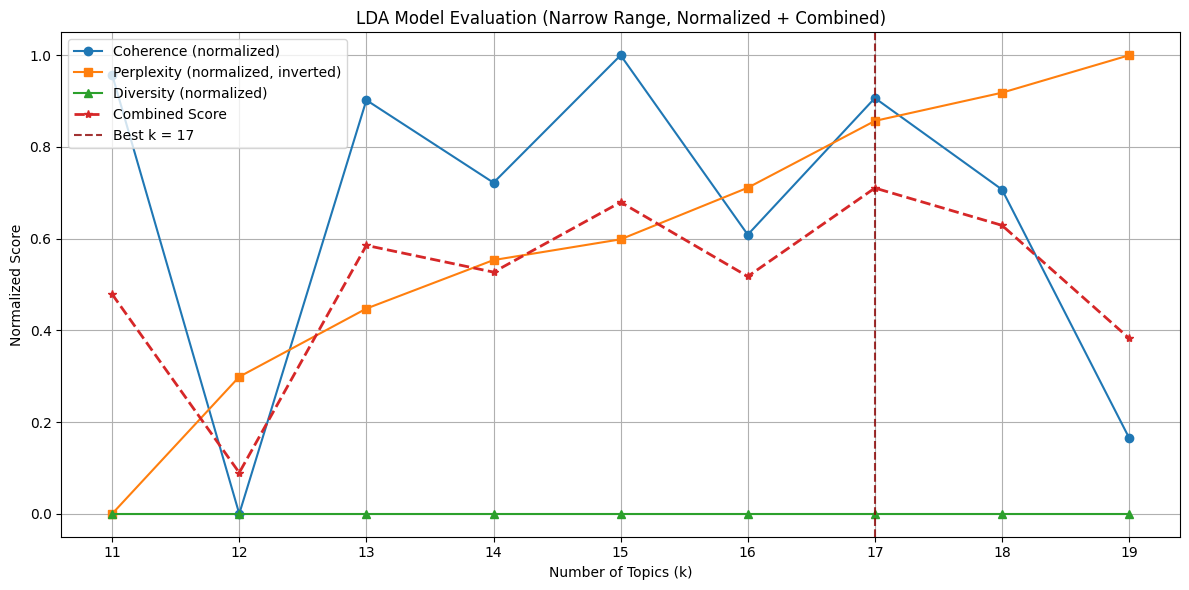

In [5]:
# --- Select narrow range based on combined score ---
# Find the k with the highest combined score
best_k_wide = wide_k_values[np.argmax(wide_combined)]
# Define narrow range around best_k_wide (±4 to ensure we capture the peak)
narrow_start = max(5, best_k_wide - 4)
narrow_end = min(60, best_k_wide + 4)
print(f"\nBest k in wide range: {best_k_wide}. Narrow range: {narrow_start} to {narrow_end}.")

# Phase 2: Narrow range (step=1)
print(f"\n=== Phase 2: Narrow range (k={narrow_start} to {narrow_end}, step=1) ===")
narrow_k_values = list(range(narrow_start, narrow_end + 1))
narrow_coherence = []
narrow_perplexity = []
narrow_diversity = []

for k in narrow_k_values:
    print(f"Training LDA with k={k}...")
    model = LdaMulticore(
        corpus=corpus, id2word=dictionary, num_topics=k,
        passes=5, chunksize=1024, workers=4, random_state=42
    )
    coherence, perplexity, diversity = evaluate_model(model, corpus, merged_docs, dictionary)
    narrow_coherence.append(coherence)
    narrow_perplexity.append(perplexity)
    narrow_diversity.append(diversity)

# Normalize narrow range metrics
narrow_coherence_norm = scaler.fit_transform(np.array(narrow_coherence).reshape(-1, 1)).flatten()
narrow_perplexity_norm = 1 - scaler.fit_transform(np.array(narrow_perplexity).reshape(-1, 1)).flatten()
narrow_diversity_norm = scaler.fit_transform(np.array(narrow_diversity).reshape(-1, 1)).flatten()

# Calculate combined score for narrow range
narrow_combined = (
    coherence_weight * narrow_coherence_norm +
    perplexity_weight * narrow_perplexity_norm +
    diversity_weight * narrow_diversity_norm
)

# Plot narrow range results
plt.figure(figsize=(12, 6))
plt.plot(narrow_k_values, narrow_coherence_norm, label='Coherence (normalized)', marker='o')
plt.plot(narrow_k_values, narrow_perplexity_norm, label='Perplexity (normalized, inverted)', marker='s')
plt.plot(narrow_k_values, narrow_diversity_norm, label='Diversity (normalized)', marker='^')
plt.plot(narrow_k_values, narrow_combined, label='Combined Score', marker='*', linestyle='--', linewidth=2)

# Add vertical line for best k in narrow range
best_k = narrow_k_values[np.argmax(narrow_combined)]
plt.axvline(x=best_k, color='darkred', linestyle='--', label=f'Best k = {best_k}', alpha=0.8)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation (Narrow Range, Normalized + Combined)")
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.savefig('viz/LDA_narrow_range_normalized_combined.png', dpi=300)
plt.show()

In [6]:
# --- 6. Select Best k (using combined score) ---
best_k = narrow_k_values[np.argmax(narrow_combined)]
print(f"\nBest number of topics (k): {best_k}")

# --- 7. Train Final Model ---
print(f"\nTraining final LDA model with k={best_k}...")
lda = LdaMulticore(
    corpus=corpus, id2word=dictionary, num_topics=best_k,
    passes=10, chunksize=1024, workers=4, random_state=42
)

# --- 8. Print Topics (Clean Format) ---
print("\nTopics:")
for idx in range(lda.num_topics):
    terms = [term for term, _ in lda.show_topic(idx, topn=20)]
    print(f"Topic {idx}: {', '.join(terms)}")

# --- 9. Assign Topics to Documents ---
doc_topics = [lda.get_document_topics(doc, minimum_probability=0.0) for doc in corpus]
df["topic"] = [sorted(topics, key=lambda x: x[1], reverse=True)[0][0] if topics else -1 for topics in doc_topics]
df["topic_prob"] = [sorted(topics, key=lambda x: x[1], reverse=True)[0][1] if topics else 0.0 for topics in doc_topics]

# --- 10. Get Clean Topic Labels ---
def get_topic_labels(model, n_words=5):
    labels = {}
    for topic_id in range(model.num_topics):
        terms = [term for term, _ in model.show_topic(topic_id, topn=n_words)]
        labels[topic_id] = ", ".join(terms)
    return labels

topic_labels = get_topic_labels(lda)
df["topic_label"] = df["topic"].map(topic_labels)

# --- 11. Visualize with pyLDAvis ---
vis_data = gensimvis.prepare(lda, corpus, dictionary)
pyLDAvis.display(vis_data)
pyLDAvis.save_html(vis_data, 'viz/lda_visualization.html')

# --- 12. Save Results ---
# lda.save('models/lda_model.gensim')
# dictionary.save('models/dictionary.gensim')


Best number of topics (k): 17

Training final LDA model with k=17...

Topics:
Topic 0: long, end, atmosphere, far, burn, fall, second, run, survive, fire, 100, need, oxygen, ground, vacuum, able, reach, mirror, walk, ball
Topic 1: different, difference, test, color, type, determine, chemical, specific, dangerous, element, reaction, change, certain, plastic, country, solution, one, home, group, chemistry
Topic 2: human, animal, specie, like, sleep, evolve, body, evolution, dog, vaccinate, control, bird, wake, population, insect, ability, live, natural, possible, mammal
Topic 3: vaccine, help, people, grow, disease, get, age, old, child, develop, cancer, baby, prevent, muscle, risk, cause, immune_system, spread, genetic, immunity
Topic 4: know, thing, actually, think, true, right, don, like, scientist, case, tell, death, occur, idea, release, cause, state, say, understand, cat
Topic 5: effect, virus, vs, impact, kill, real, climate_change, effective, drug, reduce, alcohol, health, cause